## TODO
1. create main.py and set up to specify a tianshou alg and evaluate model
2. create a continual env trainer setup - try using tianshou trainer classes
    1. takes a list of envs and trains for a specified number of steps on each
    2. logs the things you want -- e.g. test results by each env
    3. has logic for `on-task-start` and `on-task-end` etc.
3. run with a base tianshou alg (or with minimal subclassing) to baseline performance

In [297]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

results = pd.read_csv(
    r'./log\custom_continual\CartPole-v1\06072025145438_dqn\results.csv',
    )
results.head()

,training_task,eval_task,global_step,mean_rew,std_rew,min_rew,max_rew
0,0,0,5000,173.8,22.270159,150.0,233.0
1,0,1,5000,182.6,29.103952,147.0,230.0
2,0,2,5000,30.4,5.351635,22.0,38.0
3,0,0,10000,256.8,54.230619,185.0,367.0
4,0,1,10000,7.2,4.512206,3.0,19.0


C:\Users\61417\AppData\Local\Temp\ipykernel_73556\4265763761.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  tab20 = cm.get_cmap('tab10', len(unique_tasks))  # interpolate to num tasks


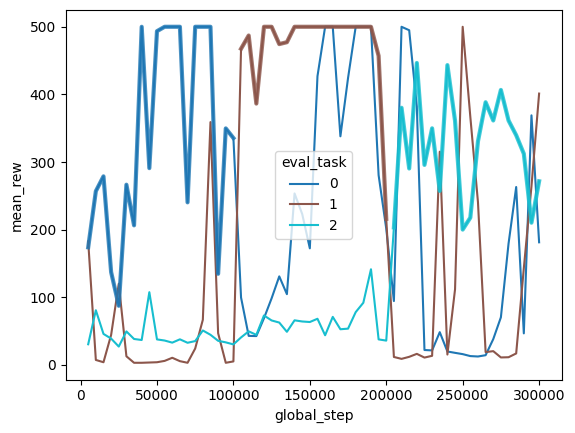

In [298]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Get unique hue values to determine how many colors you need
unique_tasks = results['eval_task'].unique()

# Use tab20 colormap from matplotlib
tab20 = cm.get_cmap('tab10', len(unique_tasks))  # interpolate to num tasks

# Convert to hex color codes
palette = [mcolors.to_hex(tab20(i)) for i in range(len(unique_tasks))]

# Map task values to specific colors
task_color_map = dict(zip(unique_tasks, palette))

results.loc[:,'training_task'] = pd.Categorical(results.training_task)
results.loc[:, 'eval_task'] = pd.Categorical(results.eval_task)
results['is_current_task'] = 1*(results.training_task==results.eval_task)
sns.lineplot(
    data=results.reset_index(),
    x='global_step',
    y='mean_rew',
    hue='eval_task',
    palette=task_color_map
)
sns.lineplot(
    data=results.query('is_current_task==1'),
    x='global_step',
    y='mean_rew',
    hue='eval_task',
    palette=task_color_map,
    linewidth=3,
    alpha=.8,
    legend=False
)

# for task in results['eval_task'].unique():
#     subset = results[results['eval_task'] == task].sort_values("global_step")
#     plt.fill_between(
#         subset['global_step'],
#         subset['min_rew'],
#         subset['max_rew'],
#         color=task_color_map[task],
#         alpha=0.2,
#         linewidth=0
#     )

plt.show();

In [275]:
import gymnasium as gym
import tianshou as ts
import torch
from algorithms.dqn import SoftDQNPolicy

ENV_NAME = "CartPole-v1"

env = gym.make(ENV_NAME)
state_shape = env.observation_space.shape or env.observation_space.n
action_shape = env.action_space.shape or env.action_space.n
net = ts.utils.net.common.Net(
    state_shape=state_shape,
    action_shape=action_shape,
    hidden_sizes = [128, 128],
    device="cpu"
)
optim = torch.optim.Adam(net.parameters(), lr = 1e-3)

policy = SoftDQNPolicy(
    model = net,
    optim = optim,
    action_space = env.action_space,
    discount_factor = 0.99,
    estimation_step = 1,
    target_update_freq=1, # each update for soft updates
    tau = 0.05 # soft update parameter for polyak averaging
)

In [ ]:
policy.load_state_dict(torch.load(r'log\custom_continual\CartPole-v1\05072025201021_dqn\policy.pth', map_location='cpu'))



<All keys matched successfully>

In [294]:
from gymnasium.wrappers import RecordVideo
from tianshou.policy import BasePolicy
from tianshou.data import Batch

def record_policy_video(policy: BasePolicy, save_dir="video"):
    env = RecordVideo(
        gym.make("CartPole-v1", render_mode="rgb_array"),
        video_folder=save_dir,
        episode_trigger=lambda ep: True  # record every episode
    )
    obs, info = env.reset()
    done = False
    step = 0
    total_reward=0

    while not done:
        batch = Batch(obs=[obs], info=[info])
        action = policy.forward(batch)  # assumes deterministic policy
        obs, reward, terminated, truncated, info = env.step(action.act[0])
        done = terminated or truncated
        step += 1
        total_reward += reward
    print(f"Achieved reward of: {total_reward}")
    env.close()

record_policy_video(policy=policy, save_dir = './tmp/')

Achieved reward of: 500.0


In [283]:
from tianshou.data import Batch
obs = [-0.02417843,  0.02196702, -0.04087185, -0.01689104]
Batch(obs=obs)


Batch(
    obs: array([-0.02417843,  0.02196702, -0.04087185, -0.01689104]),
)

In [226]:
import numpy as np

import torch
from torch import nn

class Net(nn.Module):

    def __init__(self, state_shape, action_shape):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(np.prod(state_shape), 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, np.prod(action_shape))
        )
    
    def forward(self, obs, state=None, info={}):
        if not isinstance(obs, torch.Tensor):
            ## need device?
            obs = torch.tensor(obs, dtype=torch.float)
        batch = obs.shape[0]
        logits = self.model(obs.view(batch, -1))
        ## state could be next hidden state for a RNN
        ## first output may vary on algo type (e.g. mu, sigma or logits)
        return logits, state

ENV_NAME = 'CartPole-v1'
train_envs = ts.env.DummyVectorEnv([lambda: gym.make(ENV_NAME) for _ in range(10)])
test_envs = ts.env.DummyVectorEnv([lambda: gym.make(ENV_NAME) for _ in range(100)])

env = gym.make(ENV_NAME)
state_shape = env.observation_space.shape or env.observation_space.n
action_shape = env.action_space.shape or env.action_space.n

net = Net(state_shape, action_shape)
optim = torch.optim.Adam(net.parameters(), lr = 1e-3)

## define the DQN policy
policy = ts.policy.DQNPolicy(
    model = net, # our network
    optim=optim,
    action_space=env.action_space,
    discount_factor = 0.9,
    estimation_step=1,
    target_update_freq=320
)

In [243]:
from torch.utils.tensorboard import SummaryWriter
from tianshou.utils import TensorboardLogger

writer=SummaryWriter('log/dqn/run2')
## train the policy - use OffpolicyTrainer for DQN

train_collector = ts.data.Collector(
    policy=policy, ## the dqn
    env=train_envs,
    buffer=ts.data.VectorReplayBuffer(total_size=20000, buffer_num=10), # total_size is num obs, buffer_num is number per env
    exploration_noise=True
)
test_collector = ts.data.Collector(policy, test_envs, exploration_noise=True)

trainer = ts.trainer.OffpolicyTrainer(
    policy=policy,
    train_collector=train_collector,
    test_collector=test_collector,
    max_epoch=25, step_per_epoch=10000, step_per_collect=10,
    update_per_step=0.1, episode_per_test=100, batch_size=64,
    train_fn=lambda epoch, env_step: policy.set_eps(0.1), ## could adjust this to increment epsilon
    test_fn=lambda epoch, env_step: policy.set_eps(0.05),
    stop_fn=lambda mean_rewards: mean_rewards >= 200,
    logger=TensorboardLogger(writer)
)

# .run()


In [25]:
collect_result = train_collector.collect(n_step=5000)

In [33]:
collect_result.pprint_asdict()

CollectStats
----------------------------------------
{   'collect_speed': 3533.8726718488547,
    'collect_time': 1.4148783683776855,
    'lens': array([1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]),
    'lens_stat': {'max': 1000.0, 'mean': 1000.0, 'min': 1000.0, 'std': 0.0},
    'n_collected_episodes': 9,
    'n_collected_steps': 5000,
    'returns': array([-125.91749271,  -17.13752445, -116.43168622,  -98.46604116,
       -113.44568977, -117.61594266,  -71.54676752,  -96.90127912,
        -81.46635827]),
    'returns_stat': {   'max': -17.137524452987538,
                        'mean': -93.21430909902301,
                        'min': -125.91749271376835,
                        'std': 31.709868091567085}}


In [34]:
import pickle

import numpy as np
import torch

from tianshou.data import Batch

In [35]:
data = Batch(a=4, b=[5,5], c="123", d = ("a", -2, -3))
print(data)
print(data.b)

Batch(
    a: array(4),
    b: array([5, 5]),
    c: '123',
    d: array(['a', '-2', '-3'], dtype=object),
)
[5 5]


In [36]:
import gymnasium as gym
import torch

from tianshou.data import Collector, VectorReplayBuffer
from tianshou.env import DummyVectorEnv
from tianshou.policy import PGPolicy
from tianshou.utils.net.common import Net
from tianshou.utils.net.discrete import Actor

In [38]:
env = gym.make("CartPole-v1")
test_envs = DummyVectorEnv(
    [lambda: gym.make("CartPole-v1") for _ in range(2)]
)
net = Net(env.observation_space.shape, hidden_sizes=[16,])

actor = Actor(net, env.action_space.n)
optim = torch.optim.Adam(actor.parameters(), lr=3.0e-3)
policy = PGPolicy(
    actor=actor,
    optim=optim,
    dist_fn=torch.distributions.Categorical,
    action_space=env.action_space,
    action_scaling=False,
)
test_collector=Collector(policy, test_envs)

In [39]:
collect_result = test_collector.collect(reset_before_collect=True, n_episode=9)

collect_result.pprint_asdict()

CollectStats
----------------------------------------
{   'collect_speed': 1018.4666301830583,
    'collect_time': 0.1973555088043213,
    'lens': array([10, 14, 13, 26, 11, 20, 41, 44, 22]),
    'lens_stat': {   'max': 44.0,
                     'mean': 22.333333333333332,
                     'min': 10.0,
                     'std': 11.897712198383164},
    'n_collected_episodes': 9,
    'n_collected_steps': 201,
    'returns': array([10., 14., 13., 26., 11., 20., 41., 44., 22.]),
    'returns_stat': {   'max': 44.0,
                        'mean': 22.333333333333332,
                        'min': 10.0,
                        'std': 11.897712198383164}}


In [40]:
train_env_num = 4
buffer_size = 100
train_envs = DummyVectorEnv([lambda: gym.make('CartPole-v1') for _ in range(train_env_num)])
replayBuffer = VectorReplayBuffer(buffer_size, train_env_num)

train_collector = Collector(policy, train_envs, replayBuffer)

In [49]:
train_envs.reset()
train_envs

In [50]:
train_envs.step(np.array([1,1,1,1]))

(array([[-0.03863444,  0.22697279, -0.03745413, -0.29182974],
        [-0.04373907,  0.23372693, -0.00975515, -0.2975421 ],
        [-0.04573995,  0.16802524, -0.02218059, -0.34518412],
        [-0.04486895,  0.21705343, -0.01645747, -0.31477118]],
       dtype=float32),
 array([1., 1., 1., 1.]),
 array([False, False, False, False]),
 array([False, False, False, False]),
 array([{'env_id': 0}, {'env_id': 1}, {'env_id': 2}, {'env_id': 3}],
       dtype=object))

In [41]:
train_collector.reset()
replayBuffer.reset()

print(f"Replay buffer before collecting is empty, and has length={len(replayBuffer)} \n")
n_step = 50
collect_result = train_collector.collect(n_step=n_step)
print(
    f"Replay buffer after collecting {n_step} steps has length={len(replayBuffer)}.\n"
    f"This may exceed n_step when it is not a multiple of train_env_num because of vectorization.\n",
)
collect_result.pprint_asdict()

Replay buffer before collecting is empty, and has length=0 

Replay buffer after collecting 50 steps has length=52.
This may exceed n_step when it is not a multiple of train_env_num because of vectorization.

CollectStats
----------------------------------------
{   'collect_speed': 2423.725738162179,
    'collect_time': 0.021454572677612305,
    'lens': array([12, 13]),
    'lens_stat': {'max': 13.0, 'mean': 12.5, 'min': 12.0, 'std': 0.5},
    'n_collected_episodes': 2,
    'n_collected_steps': 52,
    'returns': array([12., 13.]),
    'returns_stat': {'max': 13.0, 'mean': 12.5, 'min': 12.0, 'std': 0.5}}


c:\Users\61417\Documents\Research\tianshou_ewc\venv\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=50 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(


In [53]:
samp = replayBuffer.sample(10)
samp[0]['info']['env_id']

array([0, 0, 0, 0, 0, 0, 1, 2, 3, 3])

In [60]:
from typing import Tuple, List, Dict, Any
## step 1.
## create a continual env - switches to a new env after k steps
## returns a task_id (in info?)

class ContinualEnv(gym.Env):
    def __init__(self, envs: List[gym.Env], steps_per_env):
        self.action_space = envs[0].action_space
        self.observation_space = envs[0].observation_space

        self.envs = envs
        self.num_envs = len(envs)
        self.steps_per_env = steps_per_env
        self.steps_limit = self.num_envs * self.steps_per_env
        self.cur_step = 0
        self.cur_seq_idx = 0

    def step(self, action: Any) -> Tuple[np.ndarray, float, bool, bool, Dict]:
        obs, reward, terminated, truncated, info = self.envs[self.cur_seq_idx].step(action)
        info["task_id"] = self.cur_seq_idx

        self.cur_step += 1
        if self.cur_step % self.steps_per_env == 0:
            truncated = True
            info["TimeLimit.truncated"] = True

            self.cur_seq_idx += 1

        return obs, reward, terminated, truncated, info
    
    def reset(self) -> np.ndarray:
        return self.envs[self.cur_seq_idx].reset()


        

In [75]:
collector.buffer.sample(10)[0]['info']

Batch(
    env_id: array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0]),
    task_id: array([1, 0, 0, 0, 1, 0, 0, 1, 0, 0]),
    TimeLimit.truncated: array([False, False, False, False, False, False, False, False, False,
                                False]),
)

In [242]:
trainer

NameError: name 'trainer' is not defined

In [229]:

class Net(nn.Module):

    def __init__(self, state_shape, action_shape, mid):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(np.prod(state_shape), mid),
            nn.ReLU(inplace=True),
            # nn.Linear(128, 128),
            # nn.ReLU(inplace=True),
            nn.Linear(mid,mid),
            nn.ReLU(inplace=True),
            nn.Linear(mid, np.prod(action_shape))
        )
    
    def forward(self, obs, state=None, info={}):
        if not isinstance(obs, torch.Tensor):
            ## need device?
            obs = torch.tensor(obs, dtype=torch.float)
        batch = obs.shape[0]
        logits = self.model(obs.view(batch, -1))
        ## state could be next hidden state for a RNN
        ## first output may vary on algo type (e.g. mu, sigma or logits)
        return logits, state

In [230]:
## create custom cartpole

class ModifiableCartPole(gym.envs.classic_control.CartPoleEnv):

    def __init__(self, 
                gravity:float = 9.8, 
                masscart:float=1.0,
                masspole:float=0.1,
                length:float=0.5,
                force_mag:float=10.0,
                **kwargs
        ):
        super().__init__(**kwargs)
        self.gravity = gravity
        self.masscart = masscart
        self.masspole = masspole
        self.total_mass = self.masspole + self.masscart
        self.length = length  # actually half the pole's length
        self.polemass_length = self.masspole * self.length
        self.force_mag = force_mag

env = ModifiableCartPole(gravity=1.)
env.reset()
action=env.action_space.sample()
env.step(action)

(array([-0.0144182 , -0.20291534,  0.0377867 ,  0.2946098 ], dtype=float32),
 1.0,
 False,
 False,
 {})

In [241]:
from torch.utils.tensorboard import SummaryWriter
from torch.distributions import Categorical

writer = SummaryWriter('log/custom/run59_dqn')

N_EPOCHS = 20000
STEP_PER_EPOCH = 10
TASKS = [0, 1, 2]
NUM_ENVS = 10
PARAMS = {
    0: {},
    1: {"masspole": 0.3, "force_mag":15.0},
    2: {"masspole": 0.9, "force_mag": 2.0}
    # 0: {'id': 'CartPole-v1'}
    # 0: {'id': 'LunarLander-v3', 'enable_wind':False},
    # 1: {'id': 'LunarLander-v3', 'enable_wind': True}
}
EVAL_EPISODES = 10
UPDATE_PER_STEP=.1

eps = 1
decay = 0.99

_env = gym.make('CartPole-v1')
state_shape = _env.observation_space.shape or _env.observation_space.n
action_shape = _env.action_space.shape or _env.action_space.n

net = Net(state_shape, action_shape, 128)
optim = torch.optim.Adam(net.parameters(), lr = 3e-4)

## define the DQN policy
policy = ts.policy.DQNPolicy(
    model = net, # our network
    optim=optim,
    clip_loss_grad=False, # use huber
    action_space=_env.action_space,
    discount_factor = 0.99,
    estimation_step=1,
    target_update_freq=350 # default in tianshou is a hard update
)
# policy = ts.policy.PGPolicy(
#     actor = net, # our network
#     optim=optim,
#     dist_fn=lambda logits: Categorical(logits=logits),
#     # clip_loss_grad=True, # use huber
#     action_space=_env.action_space,
#     discount_factor = 0.99,
#     action_scaling=False
#     # estimation_step=1,
#     # target_update_freq=1 # default in tianshou is a hard update
# )
steps_so_far = 0
## for each task
for task in TASKS:
    print(f"starting task: {task} at {steps_so_far}")

    ## create an env
    # env = ts.env.DummyVectorEnv([lambda: gym.make(**PARAMS[task]) for _ in range(NUM_ENVS)])
    env = ts.env.DummyVectorEnv([lambda: ModifiableCartPole(**PARAMS[task]) for _ in range(NUM_ENVS)])
    collector = ts.data.Collector(
        policy=policy,
        env=env,
        buffer = ts.data.PrioritizedVectorReplayBuffer(
            total_size=1e6, 
            buffer_num=NUM_ENVS, 
            alpha=1.0, 
            beta=0.1 ## apparently annealing beta over time can increase learning stability
        ),
        exploration_noise=True
        
        #ts.data.VectorReplayBuffer(1e6, NUM_ENVS)
    )
    collector.reset_env()

    ## train for N_EPOCHS = NUM_ENVS * STEPS_PER_EPOCH
    for epoch in range(N_EPOCHS):
        eps *= decay**epoch
        
        results = collector.collect(
            n_step=STEP_PER_EPOCH, 
            # n_episode=10,
            reset_before_collect=False
        )
        steps_so_far += results.n_collected_steps
         
        if results.returns_stat is not None:
            stats = results.returns_stat

            writer.add_scalar(f"train/{task}_mean", stats.mean, steps_so_far)
            writer.add_scalar(f"train/{task}_std", stats.std, steps_so_far)
            writer.add_scalar(f"train/{task}_eps", eps, steps_so_far)

        ## can update policy like this...
        policy.is_within_training_step = True
        # update_results = policy.update(sample_size=1024, buffer=collector.buffer, batch_size=128, repeat=1)
        # loss = update_results.loss.mean
        # writer.add_scalar(f"train/loss", loss, steps_so_far)

        # if steps_so_far > 10000:
        num_updates = int(UPDATE_PER_STEP * results.n_collected_steps)
        loss=0
        for _ in range(num_updates):
            update_results = policy.update(128, collector.buffer)
            loss += update_results.loss
        policy.is_within_training_step = False

        writer.add_scalar(f"train/loss", loss / num_updates, steps_so_far)
        policy.set_eps(0.05)
        ## Eval one of each env
        for eval_task in TASKS:
            test_collector = ts.data.Collector(
                policy=policy,
                env = ts.env.DummyVectorEnv(
                    # [lambda: gym.make(**PARAMS[eval_task]) for _ in range(EVAL_EPISODES)]
                    [lambda: ModifiableCartPole(**PARAMS[eval_task]) for _ in range(EVAL_EPISODES)]
                )
            )
            eval_results = test_collector.collect(n_episode=EVAL_EPISODES, reset_before_collect=True)
            eval_stats = eval_results.returns_stat
            writer.add_scalar(f"test/{eval_task}_mean", eval_stats.mean, steps_so_far)
            writer.add_scalar(f"test/{eval_task}_std", eval_stats.std, steps_so_far)
        
        ## use exploration noise
        policy.set_eps(eps)
    # print(results)
    

starting task: 0 at 0


KeyboardInterrupt: 

In [234]:
results

CollectStats(n_collected_episodes=0, n_collected_steps=10, collect_time=0.014846563339233398, collect_speed=673.5565512036101, returns=array([], dtype=float64), returns_stat=None, lens=array([], dtype=int32), lens_stat=None)

In [99]:
res = collector.collect(n_step=1)
result["n/st"]

c:\Users\61417\Documents\Research\tianshou_ewc\venv\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=1 is not a multiple of (self.env_num=2), which may cause extra transitions being collected into the buffer.
  warnings.warn(


TypeError: 'InfoStats' object is not subscriptable

In [103]:
res.n_collected_steps


2

In [66]:
from torch.utils.tensorboard import SummaryWriter
from tianshou.utils import TensorboardLogger
_env = gym.make('LunarLander-v3')
state_shape = _env.observation_space.shape or _env.observation_space.n
action_shape = _env.action_space.shape or _env.action_space.n

net = Net(state_shape, action_shape)
optim = torch.optim.Adam(net.parameters(), lr = 1e-3)

## define the DQN policy
policy = ts.policy.DQNPolicy(
    model = net, # our network
    optim=optim,
    action_space=_env.action_space,
    discount_factor = 0.9,
    estimation_step=1,
    target_update_freq=320
)

## setup collector to help policy interact with different types of environments
train_collector = ts.data.Collector(
    policy=policy, ## the dqn
    env=env,
    buffer=ts.data.VectorReplayBuffer(total_size=20000, buffer_num=1), # total_size is num obs, buffer_num is number per env
    exploration_noise=True
)
test_envs = 
test_collector = ts.data.Collector(policy, env, exploration_noise=True)

writer=SummaryWriter('log/dqn')
## train the policy - use OffpolicyTrainer for DQN
result = ts.trainer.OffpolicyTrainer(
    policy=policy,
    train_collector=train_collector,
    test_collector=test_collector,
    max_epoch=10, step_per_epoch=2000, step_per_collect=10,
    update_per_step=0.1, episode_per_test=10, batch_size=64,
    train_fn=lambda epoch, env_step: policy.set_eps(0.1), ## could adjust this to increment epsilon
    test_fn=lambda epoch, env_step: policy.set_eps(0.05),
    stop_fn=lambda mean_rewards: mean_rewards >= 200,
    logger=TensorboardLogger(writer)
).run()


Epoch #1: 2001it [00:03, 605.15it/s, env_step=2000, gradient_step=200, len=52, n/ep=0, n/st=10, rew=-152.63]                           


IndexError: list index out of range